In [174]:
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import MinMaxScaler, StandardScaler


def load_data(path):
    df = pd.read_csv(path)
    return df

df = load_data(r"C:\Users\rodio\PycharmProjects\Bioinformatics\Weekly-Tasks\Week 6\datasets\csgo_round_snapshots.csv")
df.head(10)

,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0.0,0.0,de_dust2,False,500.0,500.0,0.0,0.0,4000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
1,156.03,0.0,0.0,de_dust2,False,500.0,500.0,400.0,300.0,600.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
2,96.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
3,76.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
4,174.97,1.0,0.0,de_dust2,False,500.0,500.0,192.0,0.0,18350.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
5,114.97,1.0,0.0,de_dust2,False,500.0,500.0,500.0,0.0,1750.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,CT
6,94.97,1.0,0.0,de_dust2,False,295.0,111.0,296.0,0.0,1700.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
7,74.97,1.0,0.0,de_dust2,False,295.0,111.0,296.0,0.0,1700.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
8,54.97,1.0,0.0,de_dust2,False,249.0,89.0,269.0,0.0,2300.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
9,174.97,2.0,0.0,de_dust2,False,500.0,500.0,196.0,0.0,19800.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT


In [175]:
df.describe()

,time_left,ct_score,t_score,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,...,ct_grenade_flashbang,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade
count,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,...,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000
mean,97.886922,6.709239,6.780435,412.106568,402.714500,314.142121,298.444670,9789.023773,11241.036680,2.053901,...,1.853157,1.858100,1.540814,1.627146,1.001969,0.019819,0.048011,1.352095,0.027694,0.025750
std,54.465238,4.790362,4.823543,132.293290,139.919033,171.029736,174.576545,11215.042286,12162.806759,1.841470,...,1.772791,1.794473,1.737804,1.829147,1.458084,0.143933,0.227669,1.663246,0.169531,0.164162
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.920000,3.000000,3.000000,350.000000,322.000000,194.000000,174.000000,1300.000000,1550.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,94.910000,6.000000,6.000000,500.000000,500.000000,377.000000,334.000000,5500.000000,7150.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,166.917500,10.000000,10.000000,500.000000,500.000000,486.000000,468.000000,14600.000000,18000.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000
max,175.000000,32.000000,33.000000,500.000000,600.000000,500.000000,500.000000,80000.000000,80000.000000,5.000000,...,7.000000,7.000000,6.000000,9.000000,5.000000,3.000000,3.000000,5.000000,3.000000,2.000000


In [176]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122410 entries, 0 to 122409
Data columns (total 97 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   time_left                     122410 non-null  float64
 1   ct_score                      122410 non-null  float64
 2   t_score                       122410 non-null  float64
 3   map                           122410 non-null  str    
 4   bomb_planted                  122410 non-null  bool   
 5   ct_health                     122410 non-null  float64
 6   t_health                      122410 non-null  float64
 7   ct_armor                      122410 non-null  float64
 8   t_armor                       122410 non-null  float64
 9   ct_money                      122410 non-null  float64
 10  t_money                       122410 non-null  float64
 11  ct_helmets                    122410 non-null  float64
 12  t_helmets                     122410 non-null  float64


In [177]:
df["t_grenade_flashbang"].value_counts()

t_grenade_flashbang
0.0    41241
1.0    22238
2.0    16532
5.0    16086
3.0    13537
4.0    12775
7.0        1
Name: count, dtype: int64

In [178]:
def drop_row_data(df, min_ratio, column):
     ratio = df[column].value_counts(normalize=True)*100
     drop_values = ratio.index[ratio <= min_ratio]
     return df[~(df[column].isin(drop_values))]

class RatioEstimator(BaseEstimator):
    def __init__(self, df_with_ids=False):
        self.df_with_ids = df_with_ids
    def fit(self, df, target_column, estimation_column, id_column=None):
        if self.df_with_ids:
            self.rounds_df = df.drop_duplicates(subset=[id_column])
            self.win_rates = pd.crosstab(self.rounds_df[target_column], self.rounds_df[estimation_column], normalize='index')
        else:
            is_new_round = df['time_left'].diff() > 0
            df['round_id'] = is_new_round.cumsum()
            self.id_column = 'round_id'
            self.rounds_df = df.drop_duplicates(subset=[self.id_column])
            self.win_rates = pd.crosstab(self.rounds_df[target_column], self.rounds_df[estimation_column], normalize='index')
        return self.win_rates

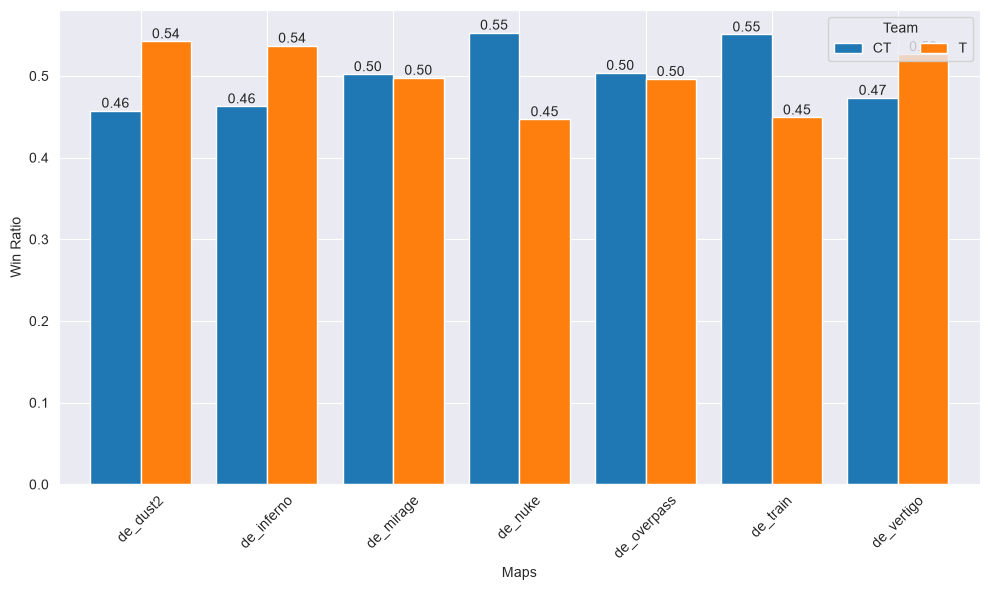

In [179]:
df = drop_row_data(df, 3, "map")

is_new_round = df['time_left'].diff() > 0

df['round_id'] = is_new_round.cumsum()

rounds_df = df.drop_duplicates(subset=['round_id'])

win_rates = pd.crosstab(rounds_df['map'], rounds_df['round_winner'], normalize='index')

fig, ax = plt.subplots(figsize=(10, 6))
win_rates[['CT', 'T']].plot(kind='bar', ax=ax, width=0.8)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

ax.set_ylabel("Win Ratio")
ax.set_xlabel("Maps")
ax.legend(title="Team", ncols=2)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [180]:
weapons = ['ct_weapon_ak47',
       't_weapon_ak47', 'ct_weapon_aug', 't_weapon_aug', 'ct_weapon_awp',
       't_weapon_awp', 'ct_weapon_bizon', 't_weapon_bizon',
       'ct_weapon_cz75auto', 't_weapon_cz75auto', 'ct_weapon_elite',
       't_weapon_elite', 'ct_weapon_famas', 't_weapon_famas',
       'ct_weapon_g3sg1', 't_weapon_g3sg1', 'ct_weapon_galilar',
       't_weapon_galilar', 'ct_weapon_glock', 't_weapon_glock',
       'ct_weapon_m249', 't_weapon_m249', 'ct_weapon_m4a1s',
       't_weapon_m4a1s', 'ct_weapon_m4a4', 't_weapon_m4a4',
       'ct_weapon_mac10', 't_weapon_mac10', 'ct_weapon_mag7',
       't_weapon_mag7', 'ct_weapon_mp5sd', 't_weapon_mp5sd',
       'ct_weapon_mp7', 't_weapon_mp7', 'ct_weapon_mp9', 't_weapon_mp9',
       'ct_weapon_negev', 't_weapon_negev', 'ct_weapon_nova',
       't_weapon_nova', 'ct_weapon_p90', 't_weapon_p90',
       'ct_weapon_r8revolver', 't_weapon_r8revolver',
       'ct_weapon_sawedoff', 't_weapon_sawedoff', 'ct_weapon_scar20',
       't_weapon_scar20', 'ct_weapon_sg553', 't_weapon_sg553',
       'ct_weapon_ssg08', 't_weapon_ssg08', 'ct_weapon_ump45',
       't_weapon_ump45', 'ct_weapon_xm1014', 't_weapon_xm1014',
       'ct_weapon_deagle', 't_weapon_deagle', 'ct_weapon_fiveseven',
       't_weapon_fiveseven', 'ct_weapon_usps', 't_weapon_usps',
       'ct_weapon_p250', 't_weapon_p250', 'ct_weapon_p2000',
       't_weapon_p2000', 'ct_weapon_tec9', 't_weapon_tec9']


# --- Counter-Terrorist (CT) Weapons ---

ct_rifles = [
    'ct_weapon_ak47', 'ct_weapon_aug', 'ct_weapon_famas', 
    'ct_weapon_galilar', 'ct_weapon_m4a1s', 'ct_weapon_m4a4', 
    'ct_weapon_sg553'
]
ct_mp = [
    'ct_weapon_bizon', 'ct_weapon_mac10', 'ct_weapon_mp5sd', 
    'ct_weapon_mp7', 'ct_weapon_mp9', 'ct_weapon_p90', 
    'ct_weapon_ump45', 'ct_weapon_m249', 'ct_weapon_negev'
]
ct_snipers = [
    'ct_weapon_awp', 'ct_weapon_g3sg1', 'ct_weapon_scar20', 
    'ct_weapon_ssg08'
]
ct_shotguns = [
    'ct_weapon_mag7', 'ct_weapon_nova', 'ct_weapon_sawedoff', 
    'ct_weapon_xm1014'
]
ct_spawn_pistols = [
    'ct_weapon_p2000', 'ct_weapon_usps'
]
ct_other_pistols = [
    'ct_weapon_cz75auto', 'ct_weapon_deagle', 'ct_weapon_elite', 
    'ct_weapon_fiveseven', 'ct_weapon_p250', 'ct_weapon_r8revolver', 
    'ct_weapon_glock', 'ct_weapon_tec9'
]

# --- Terrorist (T) Weapons ---

t_rifles = [
    't_weapon_ak47', 't_weapon_aug', 't_weapon_famas', 
    't_weapon_galilar', 't_weapon_m4a1s', 't_weapon_m4a4', 
    't_weapon_sg553'
]
t_mp = [
    't_weapon_bizon', 't_weapon_mac10', 't_weapon_mp5sd', 
    't_weapon_mp7', 't_weapon_mp9', 't_weapon_p90', 
    't_weapon_ump45', 't_weapon_m249', 't_weapon_negev'
]
t_snipers = [
    't_weapon_awp', 't_weapon_g3sg1', 't_weapon_scar20', 
    't_weapon_ssg08'
]
t_shotguns = [
    't_weapon_mag7', 't_weapon_nova', 't_weapon_sawedoff', 
    't_weapon_xm1014'
]
t_spawn_pistols = [
    't_weapon_glock'
]
t_other_pistols = [
    't_weapon_p2000', 't_weapon_usps', 't_weapon_tec9', 
    't_weapon_cz75auto', 't_weapon_deagle', 't_weapon_elite', 
    't_weapon_fiveseven', 't_weapon_p250', 't_weapon_r8revolver'
]


weapons_df = pd.DataFrame()
weapons_df["ct_rifles"] = df[ct_rifles].sum(axis=1)
weapons_df["ct_mp"] = df[ct_mp].sum(axis=1)
weapons_df["ct_snipers"] = df[ct_snipers].sum(axis=1)
weapons_df["ct_shotguns"] = df[ct_shotguns].sum(axis=1)
weapons_df["ct_spawn_pistols"] = pd.to_numeric(df[df[ct_spawn_pistols] <= 5].sum(axis=1))
weapons_df["ct_other_pistols"] = df[ct_other_pistols].sum(axis=1)

weapons_df["t_rifles"] = df[t_rifles].sum(axis=1)
weapons_df["t_mp"] = df[t_mp].sum(axis=1)
weapons_df["t_snipers"] = df[t_snipers].sum(axis=1)
weapons_df["t_shotguns"] = df[t_shotguns].sum(axis=1)
weapons_df["t_spawn_pistols"] = df[t_spawn_pistols].sum(axis=1)
weapons_df["t_other_pistols"] = df[t_other_pistols].sum(axis=1)

grenades = ['ct_grenade_hegrenade', 't_grenade_hegrenade',
       'ct_grenade_flashbang', 't_grenade_flashbang',
       'ct_grenade_smokegrenade', 't_grenade_smokegrenade',
       'ct_grenade_incendiarygrenade', 't_grenade_incendiarygrenade',
       'ct_grenade_molotovgrenade', 't_grenade_molotovgrenade',]

weapons_df['ct_grenade_hegrenade'] = df['ct_grenade_hegrenade']
weapons_df['ct_grenade_flashbang'] = df['ct_grenade_flashbang']
weapons_df['ct_grenade_smokegrenade'] = df['ct_grenade_smokegrenade']
weapons_df['ct_grenade_firegrenade'] = df[['ct_grenade_incendiarygrenade', 'ct_grenade_molotovgrenade']].sum(axis=1)

weapons_df['t_grenade_hegrenade'] = df['t_grenade_hegrenade']
weapons_df['t_grenade_flashbang'] = df['t_grenade_flashbang']
weapons_df['t_grenade_smokegrenade'] = df['t_grenade_smokegrenade']
weapons_df['t_grenade_firegrenade'] = df[['t_grenade_incendiarygrenade', 't_grenade_molotovgrenade']].sum(axis=1)


In [181]:
final_df = weapons_df.copy()
final_df["time_left"] = df["time_left"]
final_df["ct_score"] = df["ct_score"]
final_df["t_score"] = df["t_score"]
final_df["bomb_planted"] = df["bomb_planted"]
final_df["ct_health"] = df["ct_health"]
final_df["t_health"] = df["t_health"]
final_df["ct_armor"] = df["ct_armor"]
final_df["t_armor"] = df["t_armor"]
final_df["ct_helmets"] = df["ct_helmets"]
final_df["t_helmets"] = df["t_helmets"]
final_df["ct_defuse_kits"] = df["ct_defuse_kits"]
final_df["ct_players_alive"] = df["ct_players_alive"]
final_df["t_players_alive"] = df["t_players_alive"]
final_df["round_winner"] = df["round_winner"]
final_df["map"] = df["map"]
final_df["round_id"] = df["round_id"]
final_df.describe()

,ct_rifles,ct_mp,ct_snipers,ct_shotguns,ct_spawn_pistols,ct_other_pistols,t_rifles,t_mp,t_snipers,t_shotguns,...,ct_health,t_health,ct_armor,t_armor,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_id
count,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,...,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000
mean,1.909295,0.204588,0.633689,0.012955,3.353323,0.909942,2.247389,0.154468,0.342396,0.000556,...,412.112125,402.738273,314.103178,298.456778,2.052713,2.774326,1.613054,4.273692,4.266438,11859.012980
std,1.597391,0.575760,0.678954,0.117621,1.615465,1.239955,1.784669,0.519091,0.488091,0.023577,...,132.305448,139.899590,171.038788,174.571249,1.841191,2.011030,1.605786,1.205597,1.228154,6818.540406
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,350.000000,322.000000,194.000000,174.000000,0.000000,0.000000,0.000000,4.000000,4.000000,5927.000000
50%,2.000000,0.000000,1.000000,0.000000,4.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,500.000000,500.000000,377.000000,334.000000,2.000000,3.000000,1.000000,5.000000,5.000000,11913.000000
75%,3.000000,0.000000,1.000000,0.000000,5.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,500.000000,500.000000,486.000000,468.000000,4.000000,5.000000,3.000000,5.000000,5.000000,17814.000000
max,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,...,500.000000,600.000000,500.000000,500.000000,5.000000,5.000000,5.000000,5.000000,6.000000,23508.000000


In [182]:
valid_mask = (
    (final_df['ct_players_alive'] <= 5) &
    (final_df['t_players_alive'] <= 5) &

    (final_df['ct_health'] <= 500) &
    (final_df['t_health'] <= 500) &
    (final_df['ct_armor'] <= 500) &
    (final_df['t_armor'] <= 500) &
    (final_df['ct_helmets'] <= 5) &
    (final_df['t_helmets'] <= 5) &

    (final_df['ct_defuse_kits'] <= 5) &

    (final_df['ct_score'] <= 32) &
    (final_df['t_score'] <= 32) &

    ((final_df['ct_rifles'] + final_df['ct_mp'] + final_df['ct_snipers'] + final_df['ct_shotguns']) <= 5) &
    ((final_df['t_rifles'] + final_df['t_mp'] + final_df['t_snipers'] + final_df['t_shotguns']) <= 5) &

    ((final_df['ct_spawn_pistols'] + final_df['ct_other_pistols']) <= 5) &
    ((final_df['t_spawn_pistols'] + final_df['t_other_pistols']) <= 5) &

    (final_df['ct_grenade_hegrenade'] <= 5) & (final_df['t_grenade_hegrenade'] <= 5) &
    (final_df['ct_grenade_smokegrenade'] <= 5) & (final_df['t_grenade_smokegrenade'] <= 5) &
    (final_df['ct_grenade_firegrenade'] <= 5) & (final_df['t_grenade_firegrenade'] <= 5) &
    (final_df['ct_grenade_flashbang'] <= 10) & (final_df['t_grenade_flashbang'] <= 10)
)

clean_df = final_df[valid_mask].copy()
clean_df.describe()

,ct_rifles,ct_mp,ct_snipers,ct_shotguns,ct_spawn_pistols,ct_other_pistols,t_rifles,t_mp,t_snipers,t_shotguns,...,ct_health,t_health,ct_armor,t_armor,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_id
count,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.00000,122133.000000,122133.000000,...,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000,122133.000000
mean,1.910909,0.204810,0.634259,0.012969,3.352378,0.910319,2.249187,0.15461,0.342700,0.000557,...,412.035281,402.650422,314.406475,298.732202,2.054703,2.776793,1.614617,4.273063,4.265784,11858.693998
std,1.597249,0.576031,0.679023,0.117684,1.615309,1.240233,1.784519,0.51933,0.488204,0.023590,...,132.334690,139.927981,170.846814,174.429285,1.840982,2.010323,1.605800,1.205906,1.228501,6818.579369
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,350.000000,321.000000,194.000000,175.000000,0.000000,0.000000,0.000000,4.000000,4.000000,5927.000000
50%,2.000000,0.000000,1.000000,0.000000,4.000000,0.000000,2.000000,0.00000,0.000000,0.000000,...,500.000000,500.000000,378.000000,335.000000,2.000000,3.000000,1.000000,5.000000,5.000000,11913.000000
75%,3.000000,0.000000,1.000000,0.000000,5.000000,1.000000,4.000000,0.00000,1.000000,0.000000,...,500.000000,500.000000,486.000000,468.000000,4.000000,5.000000,3.000000,5.000000,5.000000,17813.000000
max,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.00000,5.000000,1.000000,...,500.000000,500.000000,500.000000,500.000000,5.000000,5.000000,5.000000,5.000000,5.000000,23508.000000


In [183]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(clean_df, groups=clean_df["round_id"]))

train_set = clean_df.iloc[train_idx].copy()
test_set = clean_df.iloc[test_idx].copy()

mm_scaler = MinMaxScaler(clip=True)

scaler_filter = [col for col in train_set.columns if col not in ["round_winner", "map", "round_id"]]

train_set[scaler_filter] = mm_scaler.fit_transform(train_set[scaler_filter])
test_set[scaler_filter] = mm_scaler.transform(test_set[scaler_filter])
train_set.describe()

,ct_rifles,ct_mp,ct_snipers,ct_shotguns,ct_spawn_pistols,ct_other_pistols,t_rifles,t_mp,t_snipers,t_shotguns,...,ct_health,t_health,ct_armor,t_armor,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_id
count,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,...,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000,97803.000000
mean,0.383714,0.041189,0.126616,0.004342,0.670742,0.181428,0.450557,0.031105,0.068599,0.000491,...,0.823744,0.805164,0.629199,0.597288,0.411286,0.556204,0.322931,0.854287,0.852968,11854.381461
std,0.319175,0.114911,0.135722,0.039385,0.323098,0.247611,0.356621,0.104129,0.097748,0.022148,...,0.264813,0.279817,0.341941,0.349039,0.367521,0.401749,0.320664,0.241263,0.245720,6826.765889
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.696000,0.642000,0.388000,0.348000,0.000000,0.000000,0.000000,0.800000,0.800000,5925.000000
50%,0.400000,0.000000,0.200000,0.000000,0.800000,0.000000,0.400000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.756000,0.672000,0.400000,0.600000,0.200000,1.000000,1.000000,11918.000000
75%,0.600000,0.000000,0.200000,0.000000,1.000000,0.200000,0.800000,0.000000,0.200000,0.000000,...,1.000000,1.000000,0.972000,0.936000,0.800000,1.000000,0.600000,1.000000,1.000000,17787.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23508.000000


In [184]:
ratio_est = RatioEstimator(df_with_ids=True)
train_ratio = ratio_est.fit(train_set, 'map', 'round_winner', 'round_id')
train_ratio

round_winner,CT,T
map,,
de_dust2,0.463647,0.536353
de_inferno,0.458761,0.541239
de_mirage,0.501754,0.498246
de_nuke,0.553650,0.446350
de_overpass,0.505623,0.494377
de_train,0.548638,0.451362
de_vertigo,0.477577,0.522423


In [185]:
train_set = pd.merge(train_set, train_ratio, on='map', how='left')
test_set = pd.merge(test_set, train_ratio, on='map', how='left')
test_set = test_set.fillna(0.50)
train_set

,ct_rifles,ct_mp,ct_snipers,ct_shotguns,ct_spawn_pistols,ct_other_pistols,t_rifles,t_mp,t_snipers,t_shotguns,...,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_winner,map,round_id,CT,T
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,CT,de_dust2,0,0.463647,0.536353
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,1.0,1.0,CT,de_dust2,0,0.463647,0.536353
2,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,0.8,0.8,CT,de_dust2,0,0.463647,0.536353
3,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,0.8,0.8,CT,de_dust2,0,0.463647,0.536353
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,1.0,1.0,CT,de_dust2,1,0.463647,0.536353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97798,0.2,0.2,0.0,0.0,0.4,0.0,0.6,0.0,0.2,0.0,...,0.4,0.8,0.2,0.4,0.8,T,de_train,23507,0.548638,0.451362
97799,0.2,0.0,0.0,0.0,1.0,0.0,0.2,0.0,0.2,0.0,...,0.2,0.4,0.2,1.0,1.0,T,de_train,23508,0.548638,0.451362
97800,0.2,0.0,0.0,0.0,0.2,0.8,0.6,0.0,0.2,0.0,...,0.6,1.0,0.2,1.0,1.0,T,de_train,23508,0.548638,0.451362
97801,0.2,0.0,0.0,0.0,0.2,0.8,0.8,0.0,0.2,0.0,...,0.6,1.0,0.2,1.0,1.0,T,de_train,23508,0.548638,0.451362


In [186]:
label_map = {
    "CT" : 1,
    "T": 0
}

X_train = train_set.drop(columns=['map', 'round_winner', 'round_id'])
y_train = train_set['round_winner'].copy().map(label_map)
X_test = test_set.drop(columns=['map', 'round_winner', 'round_id'])
y_test = test_set['round_winner'].copy().map(label_map)

In [ ]:
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

metrics_report = []

for model_name, model in models.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    train_time = time.time() - start_time
    
    metrics_report.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (CT)": precision_score(y_test, y_pred),
        "Recall (CT)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": round(train_time, 2)
    })

report_df = pd.DataFrame(metrics_report)

report_df = report_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)


print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

C:\Users\rodio\AppData\Local\Temp\ipykernel_3888\1525139277.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', ax=ax, palette='mako')


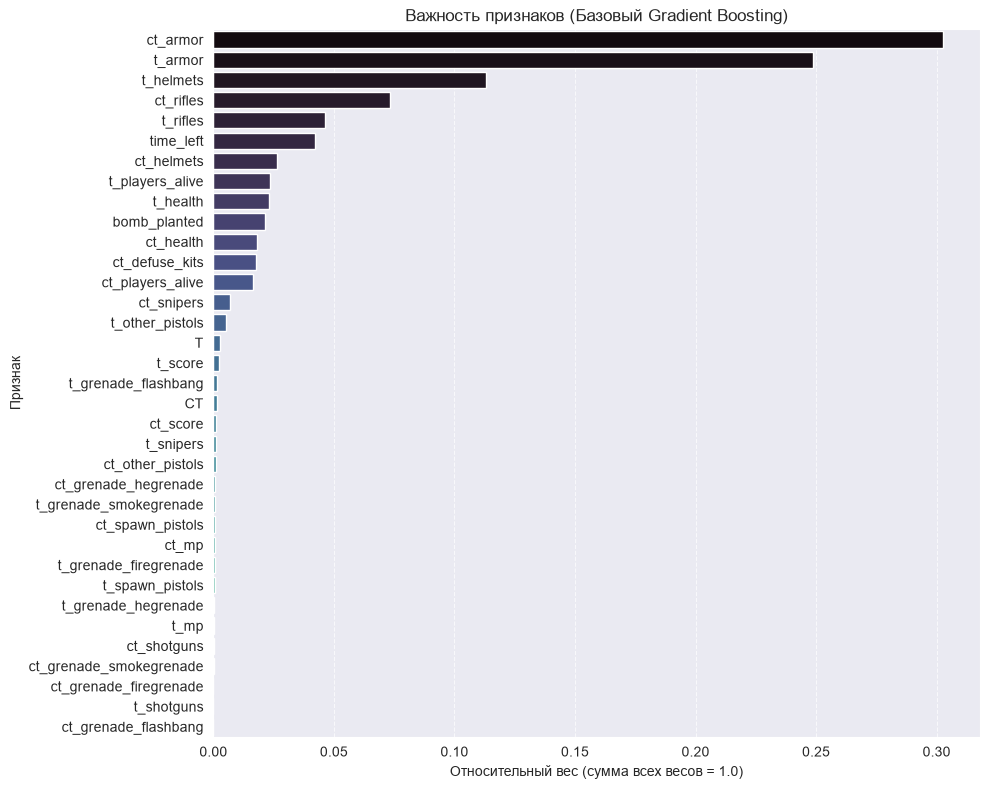


--- КАНДИДАТЫ НА УДАЛЕНИЕ (Важность < 1%) ---
                Feature  Importance
               ct_armor    0.302848
                t_armor    0.248529
              t_helmets    0.113263
              ct_rifles    0.073362
               t_rifles    0.046325
              time_left    0.042050
             ct_helmets    0.026378
        t_players_alive    0.023384
               t_health    0.023065
           bomb_planted    0.021331
              ct_health    0.018211
         ct_defuse_kits    0.017669
       ct_players_alive    0.016278
             ct_snipers    0.006957
        t_other_pistols    0.005159
                      T    0.002754
                t_score    0.002268
    t_grenade_flashbang    0.001509
                     CT    0.001462
               ct_score    0.001290
              t_snipers    0.001147
       ct_other_pistols    0.001030
   ct_grenade_hegrenade    0.000650
 t_grenade_smokegrenade    0.000542
       ct_spawn_pistols    0.000501
                 

In [165]:
model_for_importance = models["Gradient Boosting"]

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_for_importance.feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importances, x='Importance', y='Feature', ax=ax, palette='mako')

ax.set_title("Важность признаков (Базовый Gradient Boosting)")
ax.set_xlabel("Относительный вес")
ax.set_ylabel("Признак")
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(importances[importances['Importance'] < 100].to_string(index=False))